In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import json
import os
import glob

In [6]:
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json
# else:
#   print("Lab files already downloaded")
#!mkdir = "/content/adsync"
#!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync

path = "/kaggle/input/secure10k-json/"
data = {}

json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

In [8]:
import pandas as pd
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()

In [12]:
import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))

In [13]:
nodes.head()nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
#nodes.head()

,id,labels,properties,type,start,end,label,l1,l2,l3
0,6221,"[Base, Domain]","{'domain': 'TESTLAB.LOCALE', 'name': 'TESTLAB....",node,NaN,NaN,NaN,Base,Domain,None
1,6222,"[Base, OU]","{'domain': 'TESTLAB.LOCALE', 'name': 'Admin@TE...",node,NaN,NaN,NaN,Base,OU,None
2,6223,"[Base, OU]","{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 1 S...",node,NaN,NaN,NaN,Base,OU,None
3,6224,"[Base, OU]","{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 2@T...",node,NaN,NaN,NaN,Base,OU,None
4,6225,"[Base, OU]","{'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin...",node,NaN,NaN,NaN,Base,OU,None


In [14]:
nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
nodes.head()

,id,properties,type,l1,l2,l3
0,6221,"{'domain': 'TESTLAB.LOCALE', 'name': 'TESTLAB....",node,Base,Domain,None
1,6222,"{'domain': 'TESTLAB.LOCALE', 'name': 'Admin@TE...",node,Base,OU,None
2,6223,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 1 S...",node,Base,OU,None
3,6224,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 2@T...",node,Base,OU,None
4,6225,"{'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin...",node,Base,OU,None


In [16]:
nodes['id'] = nodes['id'].astype(int)
nodes.head()

,id,properties,type,l1,l2,l3
0,6221,"{'domain': 'TESTLAB.LOCALE', 'name': 'TESTLAB....",node,Base,Domain,None
1,6222,"{'domain': 'TESTLAB.LOCALE', 'name': 'Admin@TE...",node,Base,OU,None
2,6223,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 1 S...",node,Base,OU,None
3,6224,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 2@T...",node,Base,OU,None
4,6225,"{'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin...",node,Base,OU,None


In [18]:
#import numpy as np
edges['id'] = edges['id'].astype(int)
edges.head()

,id,labels,properties,type,start,end,label
10075,0,NaN,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6222', 'labels': ['Base', 'OU']}",Contains
10076,1,NaN,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6223', 'labels': ['Base', 'OU']}",Contains
10077,2,NaN,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6224', 'labels': ['Base', 'OU']}",Contains
10078,3,NaN,{},relationship,"{'id': '6222', 'labels': ['Base', 'OU']}","{'id': '6225', 'labels': ['Base', 'OU']}",Contains
10079,4,NaN,{},relationship,"{'id': '6222', 'labels': ['Base', 'OU']}","{'id': '6226', 'labels': ['Base', 'OU']}",Contains


In [21]:
nodes.keys
edges.keys


<bound method NDFrame.keys of           id labels                                         properties  \
10075      0    NaN                                                 {}   
10076      1    NaN                                                 {}   
10077      2    NaN                                                 {}   
10078      3    NaN                                                 {}   
10079      4    NaN                                                 {}   
...      ...    ...                                                ...   
58391  48316    NaN  {'isacl': True, 'isInherited': True, 'inherita...   
58392  48317    NaN  {'isacl': True, 'isInherited': False, 'inherit...   
58393  48318    NaN  {'isacl': True, 'isInherited': False, 'inherit...   
58394  48319    NaN  {'isacl': True, 'isInherited': False, 'inherit...   
58395  48320    NaN  {'isacl': True, 'isInherited': False, 'inherit...   

               type                                         start  \
10075  relat

In [22]:
#nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
edges = edges.drop(columns=['labels'])
nodes['weight'] = 1

In [24]:
edges.head()

,id,properties,type,start,end,label
10075,0,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6222', 'labels': ['Base', 'OU']}",Contains
10076,1,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6223', 'labels': ['Base', 'OU']}",Contains
10077,2,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6224', 'labels': ['Base', 'OU']}",Contains
10078,3,{},relationship,"{'id': '6222', 'labels': ['Base', 'OU']}","{'id': '6225', 'labels': ['Base', 'OU']}",Contains
10079,4,{},relationship,"{'id': '6222', 'labels': ['Base', 'OU']}","{'id': '6226', 'labels': ['Base', 'OU']}",Contains


In [25]:
if 'properties' in nodes.columns:
    # Use .loc to avoid SettingWithCopyWarning and access the nested 'highvalue' key
    # We use a lambda function with .apply to safely access nested dictionary keys.
    high_value_node_ids = nodes[nodes['properties'].apply(lambda x: x.get('highvalue', False) == True)]['id'].tolist()
    print(high_value_node_ids)
else:
    print("Error: The 'Properties' column was not found in the nodes DataFrame.")

[6221, 6261, 6263, 6265, 6284, 6285, 6290, 6291, 6296, 6297, 6300, 6308, 6315, 6316, 6317, 6318, 6319, 6320, 6321, 6322, 6323, 6373, 6374, 6375, 6376, 6377, 6378, 6379, 6380, 6381, 6382, 6383, 6384, 6385, 6386, 6387, 6388, 6389, 6390, 6391, 6392, 6393, 6394, 6395, 6396, 6397, 6398, 6399, 6400, 6401, 6402, 6404, 6405, 6406, 6407, 6408, 6409, 6410, 6411, 6412, 6413, 6415, 6416, 6417, 6418, 6419, 6421, 6422, 6423, 6424, 6425, 6427, 6428, 6429, 6430, 6431, 6432, 6433, 6434, 6435, 6436, 6437, 6438, 6439, 6440, 6441, 6442, 6443, 6444, 6445, 6446, 6447, 6448, 6449, 6450, 6451, 6452, 6453, 6454, 6455, 6456, 6457, 6458, 6459, 6460, 6461, 6462, 6463, 6464, 6465, 6466, 6467, 6468, 6469, 6470, 6471, 6472, 6473, 6474, 6475, 6476, 6477, 6478, 6479, 6480, 6481, 6482, 6483, 6484, 6485, 6487, 6488, 6489, 6490, 6491, 6493, 6495, 6497, 6498, 6499, 6500, 6501, 6502, 6503, 6504, 6505, 6506, 6507, 6508, 6509, 6510, 6511, 6512, 6513, 6514, 6515, 6516, 6517, 6519, 6520, 6521, 6522, 6523, 6524, 6525, 6526, 652

In [26]:
tier_0_t0_ids = []
for index, row in nodes.iterrows():
    properties = row.get('properties')
    if properties and isinstance(properties, dict):
        distinguishedname = properties.get('distinguishedname')
        if distinguishedname and ('Tier 0' in distinguishedname or 'T0' in distinguishedname or 'TIER 0' in distinguishedname):
            tier_0_t0_ids.append(row['id'])

print("tier 0: ", tier_0_t0_ids)
len_tier0=len(tier_0_t0_ids)
print(len_tier0)

tier_1_t0_ids = []
for index, row in nodes.iterrows():
    properties = row.get('properties')
    if properties and isinstance(properties, dict):
        distinguishedname = properties.get('distinguishedname')
        if distinguishedname and ('Tier 1' in distinguishedname or 'T1' in distinguishedname or 'TIER 1' in distinguishedname):
            tier_1_t0_ids.append(row['id'])

print("tier 1: ",tier_1_t0_ids)
len_tier1=len(tier_1_t0_ids)
print(len_tier1)

tier_2_t0_ids = []
for index, row in nodes.iterrows():
    properties = row.get('properties')
    if properties and isinstance(properties, dict):
        distinguishedname = properties.get('distinguishedname')
        if distinguishedname and ('Tier 2' in distinguishedname or 'T2' in distinguishedname or 'TIER 2' in distinguishedname):
            tier_2_t0_ids.append(row['id'])

print("tier 2: ",tier_2_t0_ids)
len_tier2= len(tier_2_t0_ids)
print(len_tier2)
total = len_tier0 + len_tier1 + len_tier2
print("total: ",total)

tier 0:  [6225, 6228, 6229, 6230, 6231, 6373, 6374, 6375, 6376, 6377, 6378, 6381, 6387, 6389, 6390, 6401, 6406, 6409, 6412, 6416, 6424, 6425, 6429, 6430, 6431, 6433, 6434, 6437, 6438, 6445, 6446, 6447, 6450, 6452, 6458, 6459, 6460, 6461, 6462, 6463, 6465, 6467, 6469, 6471, 6476, 6478, 6482, 6483, 6484, 6485, 6490, 6497, 6502, 6503, 6509, 6510, 6511, 6512, 6515, 6520, 6529, 6530, 6534, 6536, 6538, 6540, 6542, 6544, 6546, 6550, 6551, 6559, 6563, 6564, 6568, 6572, 6574, 6576, 6578, 6579, 6587, 6593, 6595, 6597, 6603, 6604, 6608, 6609, 6610, 6612, 6615, 6616, 6622, 6628, 6633, 6635, 6640, 6643, 6651, 6652, 6660, 6664, 6671, 6674, 6678, 6679, 6684, 6686, 6688, 6689, 6697, 6698, 6699, 6704, 6781, 6800, 6801, 6824, 6826, 6830, 6838, 6858, 6862, 6902, 6956, 6978, 6982, 7003, 7009, 7012, 7076, 7094, 7104, 7144, 7157, 7167, 7188, 7210, 7233, 7237, 7255, 7278, 7282, 7295, 7301, 7329, 7331, 7335, 7341, 7345, 7346, 7373, 7381, 7415, 7433, 7451, 7454, 7500, 7528, 7547, 7569, 7583, 7596, 7622, 7631, 

In [27]:
total_tier0 = []
for nodeid in tier_0_t0_ids:
  if nodeid not in high_value_node_ids:
    total_tier0.append(nodeid)

print("Nodes in tier_0_t0_ids that are not in high_value_node_ids:", total_tier0)

Nodes in tier_0_t0_ids that are not in high_value_node_ids: [6225, 6228, 6229, 6230, 6231, 6704, 6781, 6800, 6801, 6824, 6826, 6830, 6838, 6858, 6862, 6902, 6956, 6978, 6982, 7003, 7009, 7012, 7076, 7094, 7104, 7144, 7157, 7167, 7188, 7210, 7233, 7237, 7255, 7278, 7282, 7295, 7301, 7329, 7331, 7335, 7341, 7345, 7346, 7373, 7381, 7415, 7433, 7451, 7454, 7500, 7528, 7547, 7569, 7583, 7596, 7622, 7631, 7667, 7670, 7686, 7687, 7700, 7704, 7705, 7775, 7801, 7809, 7813, 7829, 7854, 7882, 7887, 7888, 7918, 7940, 7982, 7993, 8036, 8091, 8093, 8097, 8113, 8154, 8181, 8199, 8200, 8236, 8257, 8258, 8296, 8314, 8325, 8378, 8384, 8403, 8442, 8452, 8454, 8458, 8459, 8482, 8503, 8510, 8519, 8532, 8533, 8536, 8567, 8584, 8593, 8608, 8617, 8623, 8637, 8677, 8681, 8725, 8727, 8729, 8743, 8746, 8756, 8757, 8783, 8784, 8797, 8834, 8853, 8858, 8861, 8865, 8877, 8881, 8883, 8896, 8918, 8924, 8940, 8946, 8949, 8982, 9015, 9022, 9023, 9025, 9060, 9077, 9099, 9145, 9170, 9207, 9260, 9261, 9275, 9283, 9296, 932

In [28]:
tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0']
        )
    )
]['id'].tolist()


tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    )
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']
        )
    )
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))

tier 0  516
tier 1  701
tier 2  8933


In [29]:
def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "tier0":
        return 20
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
edges.head()


Edges_all DataFrame with weight column:


,id,properties,type,start,end,label,weight
10075,0,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6222', 'labels': ['Base', 'OU']}",Contains,2
10076,1,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6223', 'labels': ['Base', 'OU']}",Contains,2
10077,2,{},relationship,"{'id': '6221', 'labels': ['Base', 'Domain']}","{'id': '6224', 'labels': ['Base', 'OU']}",Contains,2
10078,3,{},relationship,"{'id': '6222', 'labels': ['Base', 'OU']}","{'id': '6225', 'labels': ['Base', 'OU']}",Contains,2
10079,4,{},relationship,"{'id': '6222', 'labels': ['Base', 'OU']}","{'id': '6226', 'labels': ['Base', 'OU']}",Contains,2


In [30]:
edges['start'] = edges['start'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges['end'] = edges['end'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges.head(30)

,id,properties,type,start,end,label,weight
10075,0,{},relationship,6221,6222,Contains,2
10076,1,{},relationship,6221,6223,Contains,2
10077,2,{},relationship,6221,6224,Contains,2
10078,3,{},relationship,6222,6225,Contains,2
10079,4,{},relationship,6222,6226,Contains,2
10080,5,{},relationship,6222,6227,Contains,2
10081,6,{},relationship,6225,6228,Contains,2
10082,7,{},relationship,6225,6229,Contains,2
10083,8,{},relationship,6225,6230,Contains,2
10084,9,{},relationship,6225,6231,Contains,2


In [31]:
edges['start'] = edges['start'].astype('int64')
edges['end'] = edges['end'].astype('int64')

In [33]:
selected_edges_t2 = edges[edges['start'].isin(tier2_node_ids)]
selected_edges_t2

,id,properties,type,start,end,label,weight
10089,14,{},relationship,6227,6236,Contains,2
10090,15,{},relationship,6227,6237,Contains,2
10091,16,{},relationship,6227,6238,Contains,2
10092,17,{},relationship,6227,6239,Contains,2
10096,21,{},relationship,6224,6243,Contains,2
...,...,...,...,...,...,...,...
58282,48207,"{'isacl': False, 'isInherited': False, 'inheri...",relationship,13830,6256,AdminTo,8
58283,48208,"{'isacl': False, 'isInherited': False, 'inheri...",relationship,13830,6251,AdminTo,8
58284,48209,"{'isacl': False, 'isInherited': False, 'inheri...",relationship,13831,6256,AdminTo,8
58285,48210,"{'isacl': False, 'isInherited': False, 'inheri...",relationship,13831,6257,AdminTo,8


In [32]:
selected_edges_t1 = edges[edges['start'].isin(tier1_node_ids)]
selected_edges_t1

,id,properties,type,start,end,label,weight
10085,10,{},relationship,6226,6232,Contains,2
10086,11,{},relationship,6226,6233,Contains,2
10087,12,{},relationship,6226,6234,Contains,2
10088,13,{},relationship,6226,6235,Contains,2
10093,18,{},relationship,6223,6240,Contains,2
...,...,...,...,...,...,...,...
58231,48156,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,6318,6240,WriteDacl,5
58232,48157,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,6318,6259,WriteOwner,7
58233,48158,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,6318,6257,GenericWrite,2
58234,48159,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,6318,12982,AddMember,5


In [34]:
selected_edges_t0 = edges[edges['start'].isin(tier0_node_ids)]
selected_edges_t0

,id,properties,type,start,end,label,weight
10081,6,{},relationship,6225,6228,Contains,2
10082,7,{},relationship,6225,6229,Contains,2
10083,8,{},relationship,6225,6230,Contains,2
10084,9,{},relationship,6225,6231,Contains,2
10114,39,{},relationship,6230,6290,Contains,2
...,...,...,...,...,...,...,...
58170,48095,{},relationship,6635,6328,HasSession,9
58171,48096,{},relationship,6664,6329,HasSession,9
58172,48097,{},relationship,6689,6329,HasSession,9
58173,48098,{},relationship,6697,6328,HasSession,9


In [35]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48321 entries, 10075 to 58395
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          48321 non-null  int64 
 1   properties  48321 non-null  object
 2   type        48321 non-null  object
 3   start       48321 non-null  int64 
 4   end         48321 non-null  int64 
 5   label       48321 non-null  object
 6   weight      48321 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.9+ MB


In [37]:
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]

In [39]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t2.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['start'], row['end'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        if target in tier0_node_ids
    }
    for source, paths in shortest_paths.items()
}

# Print the shortest paths (optional)
for source, paths in shortest_paths_filtered.items():
  if paths:
    #print(f"Shortest paths from node {source}:")
    for target, path in paths.items():
        #print(f"  To node {target}: {path}")
        ShortestPath = source, target, path
 #       print(ShortestPath)

In [40]:
shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': source,
                'target': target,
                'path': path,
            })

with open('shortest_paths.json', 'w') as f:
    json.dump(shortest_paths_list, f, indent=4)

print("Shortest paths saved to shortest_paths.json")

Shortest paths saved to shortest_paths.json


In [41]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_edges_json = selected_edges_t2.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_edges_t2.json', 'w') as f:
  f.write(selected_edges_json)

In [42]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
edges_json = edges.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('edges.json', 'w') as f:
  f.write(edges_json)

In [43]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
nodes_json = nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('nodes.json', 'w') as f:
  f.write(nodes_json)

In [44]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_nodes_json = selected_nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_nodes.json', 'w') as f:
  f.write(selected_nodes_json)

In [45]:
# prompt: export shortest_paths_filtered to json and save as shortest_paths_filtered_json

shortest_paths_filtered_json = json.dumps(ShortestPath, indent=2)

# Optionally, save the JSON string to a file
with open('ShortestPath.json', 'w') as f:
  f.write(shortest_paths_filtered_json)

In [46]:
# prompt: find the corresponding record in edges where (edges['start']=shortest_paths_list['source']) and (edges['end']=shortest_paths_list['target'] and then add up the weight

# Calculate the total weight for each shortest path
shortest_paths_with_weight = []
for path_info in shortest_paths_list:
    total_weight = 0
    # The path is a list of node IDs
    path = path_info['path']
    # Iterate through the path to get the edges
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        # Find the corresponding edge in the 'edges' DataFrame
        # There might be multiple edges between two nodes, so we sum up weights if needed
        # For shortest path, we typically consider the direct edge weight
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            # Assuming there is only one edge with this start and end for simplicity in path finding
            # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
            total_weight += edge.iloc[0]['weight']
    path_info['total_weight'] = total_weight
    shortest_paths_with_weight.append(path_info)

In [47]:
import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [48]:
max_weight = df_shortest_paths_with_weight.loc[[df_shortest_paths_with_weight['total_weight'].idxmax()]].reset_index(drop=True)
max_weight

,source,target,path,total_weight
0,9700,7622,"[9700, 6580, 6322, 13004, 13827, 6250, 9779, 7...",36


In [50]:
# prompt: save max_weight to json

# Convert the max_weight DataFrame to a JSON string
max_weight_json = max_weight.to_json(orient='records', indent=2)

# Define the filename
filename = 'max_weight.json'

# Save the JSON string to a file
with open(filename, 'w') as f:
  f.write(max_weight_json)

print(f"max_weight DataFrame saved to {filename}")

max_weight DataFrame saved to max_weight.json


In [51]:
min_weight = df_shortest_paths_with_weight.loc[[df_shortest_paths_with_weight['total_weight'].idxmin()]].reset_index(drop=True)
min_weight

,source,target,path,total_weight
0,6236,6433,"[6236, 6433]",2


In [52]:
# prompt: save max_weight to json

# Convert the max_weight DataFrame to a JSON string
min_weight_json = min_weight.to_json(orient='records', indent=2)

# Define the filename
filename = 'min_weight.json'

# Save the JSON string to a file
with open(filename, 'w') as f:
  f.write(min_weight_json)

print(f"min_weight DataFrame saved to {filename}")

min_weight DataFrame saved to min_weight.json


In [53]:
# prompt: using the data in min_weight draw the attack path. use spacing to enable the edges to be read

# Get the source node ID from the min_weight DataFrame
source_id_min = min_weight['source'].iloc[0]

# Get the target node ID from the min_weight DataFrame
target_id_min = min_weight['target'].iloc[0]

# Get the path from the min_weight DataFrame
path_ids_min = min_weight['path'].iloc[0]

# Find the node names for each node in the path
path_node_names_min = []
for node_id in path_ids_min:
    node_name = nodes[nodes['id'] == node_id]['properties'].iloc[0]['name']
    path_node_names_min.append(node_name)

# Print the attack path with spacing
print("Attack Path (Min Weight):")
print(" -> ".join(path_node_names_min))

# Print the edges along the attack path with their labels and weights
print("\nEdges along the Attack Path (Min Weight):")
for i in range(len(path_ids_min) - 1):
    start_node_id = path_ids_min[i]
    end_node_id = path_ids_min[i+1]
    # Find the edge in the edges DataFrame
    edge_info = edges[(edges['start'] == start_node_id) & (edges['end'] == end_node_id)]
    if not edge_info.empty:
        edge_label = edge_info.iloc[0]['label']
        edge_weight = edge_info.iloc[0]['weight']
        start_node_name = nodes[nodes['id'] == start_node_id]['properties'].iloc[0]['name']
        end_node_name = nodes[nodes['id'] == end_node_id]['properties'].iloc[0]['name']
        print(f"{start_node_name} --[{edge_label}, Weight: {edge_weight}]--> {end_node_name}")

Attack Path (Min Weight):
T2 Admin Accounts@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE

Edges along the Attack Path (Min Weight):
T2 Admin Accounts@TESTLAB.LOCALE --[Contains, Weight: 2]--> MECKERT00061@TESTLAB.LOCALE


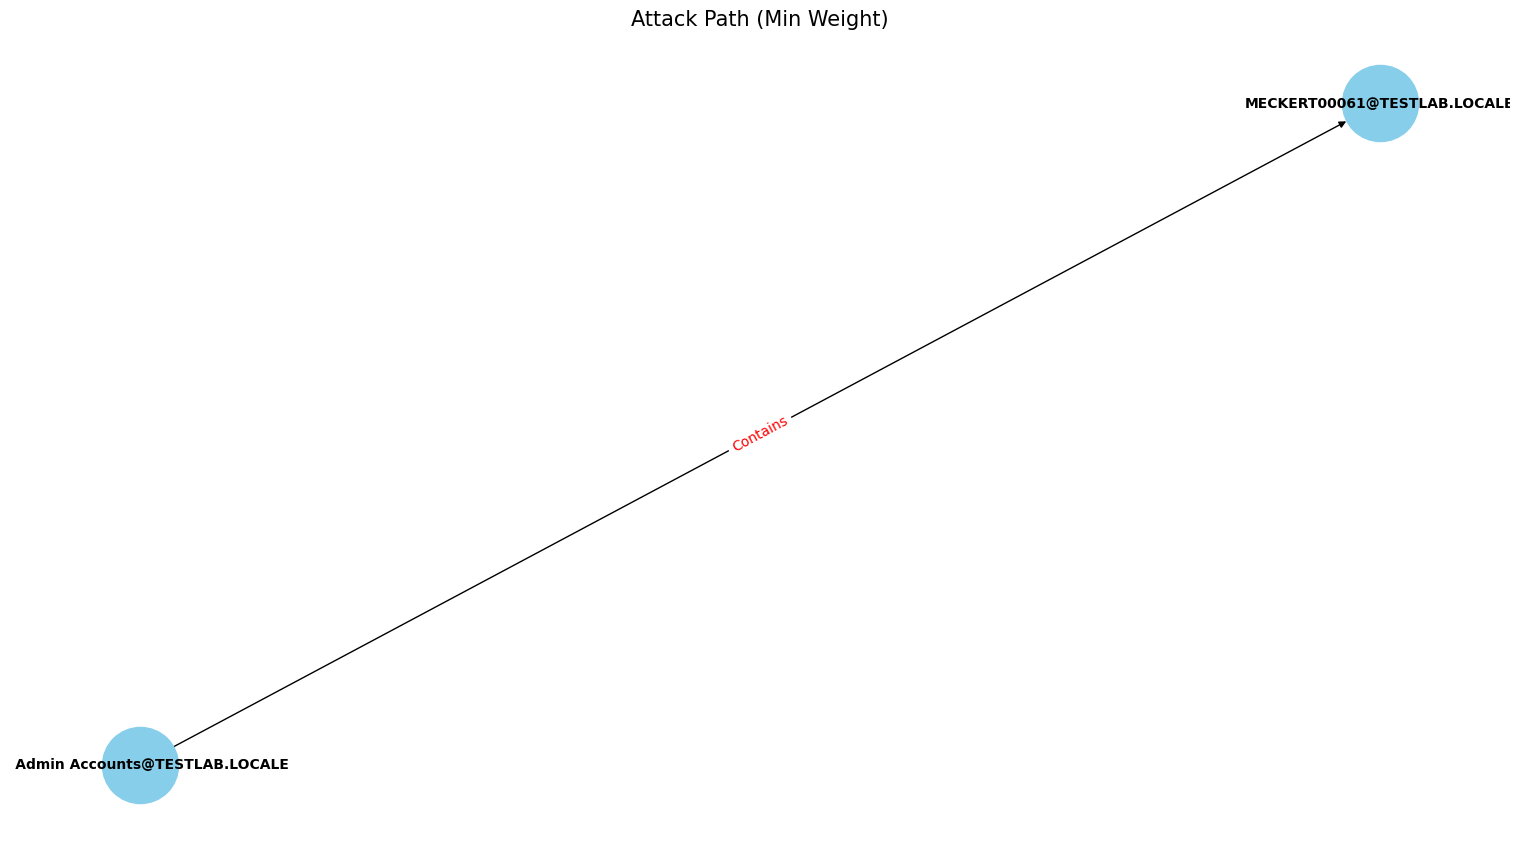

In [54]:
# prompt: using the data in min_weight draw the attack path using matplotlib.pyplot

import matplotlib.pyplot as plt

# Get the path nodes and their names
path_ids_min = min_weight['path'].iloc[0]
path_node_names_min = [nodes[nodes['id'] == node_id]['properties'].iloc[0]['name'] for node_id in path_ids_min]

# Create a directed graph for the path
attack_path_graph = nx.DiGraph()

# Add nodes to the graph
for i, node_id in enumerate(path_ids_min):
    attack_path_graph.add_node(node_id, name=path_node_names_min[i])

# Add edges with weights and labels
for i in range(len(path_ids_min) - 1):
    start_node_id = path_ids_min[i]
    end_node_id = path_ids_min[i+1]
    edge_info = edges[(edges['start'] == start_node_id) & (edges['end'] == end_node_id)]
    if not edge_info.empty:
        edge_label = edge_info.iloc[0]['label']
        edge_weight = edge_info.iloc[0]['weight']
        attack_path_graph.add_edge(start_node_id, end_node_id, label=edge_label, weight=edge_weight)

# Get node names for labels
node_labels = nx.get_node_attributes(attack_path_graph, 'name')

# Get edge labels for display
edge_labels = nx.get_edge_attributes(attack_path_graph, 'label')

# Draw the graph
plt.figure(figsize=(15, 8))
pos = nx.spring_layout(attack_path_graph, seed=40)  # You can choose a different layout algorithm

nx.draw(attack_path_graph, pos, with_labels=True, labels=node_labels, node_size=3000, node_color='skyblue', font_size=10, font_weight='bold', arrows=True)

# Draw edge labels
nx.draw_networkx_edge_labels(attack_path_graph, pos, edge_labels=edge_labels, font_color='red')

plt.title("Attack Path (Min Weight)", fontsize=15)
plt.axis('off')
plt.show()

In [55]:
# prompt: using the data in min_weight draw the attack path. use spacing to enable the edges to be read

# Get the source node ID from the min_weight DataFrame
source_id_max = max_weight['source'].iloc[0]

# Get the target node ID from the min_weight DataFrame
target_id_max = max_weight['target'].iloc[0]

# Get the path from the min_weight DataFrame
path_ids_max = max_weight['path'].iloc[0]

# Find the node names for each node in the path
path_node_names_max = []
for node_id in path_ids_max:
    node_name_max = nodes[nodes['id'] == node_id]['properties'].iloc[0]['name']
    path_node_names_max.append(node_name)

# Print the attack path with spacing
print("Attack Path (Min Weight):")
print(" -> ".join(path_node_names_max))

# Print the edges along the attack path with their labels and weights
print("\nEdges along the Attack Path (Min Weight):")
for i in range(len(path_ids_max) - 1):
    start_node_id_max = path_ids_max[i]
    end_node_id_max = path_ids_max[i+1]
    # Find the edge in the edges DataFrame
    edge_info = edges[(edges['start'] == start_node_id_max) & (edges['end'] == end_node_id_max)]
    if not edge_info.empty:
        edge_label = edge_info.iloc[0]['label']
        edge_weight = edge_info.iloc[0]['weight']
        start_node_name = nodes[nodes['id'] == start_node_id_max]['properties'].iloc[0]['name']
        end_node_name = nodes[nodes['id'] == end_node_id_max]['properties'].iloc[0]['name']
        print(f"{start_node_name} --[{edge_label}, Weight: {edge_weight}]--> {end_node_name}")

Attack Path (Min Weight):
MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE -> MECKERT00061@TESTLAB.LOCALE

Edges along the Attack Path (Min Weight):
PAW-00005@TESTLAB.LOCALE --[HasSession, Weight: 9]--> MSTENBERG00210@TESTLAB.LOCALE
MSTENBERG00210@TESTLAB.LOCALE --[MemberOf, Weight: 1]--> T2 Service Accounts Group@TESTLAB.LOCALE
T2 Service Accounts Group@TESTLAB.LOCALE --[AddMember, Weight: 5]--> T2 Security IT@TESTLAB.LOCALE
T2 Security IT@TESTLAB.LOCALE --[Contains, Weight: 2]--> T2_IT Local Admins 0@TESTLAB.LOCALE
T2_IT Local Admins 0@TESTLAB.LOCALE --[AdminTo, Weight: 8]--> T2 Workstations AK@TESTLAB.LOCALE
T2 Workstations AK@TESTLAB.LOCALE --[Contains, Weight: 2]--> WS-00068@TESTLAB.LOCALE
WS-00068@TESTLAB.LOCALE --[HasSession, Weight: 9]--> RTENNETT01252@TESTLAB.LOCALE


In [56]:
# prompt: create a table that contains the mappings from node['id'] to name from nodes where nodes['id']=max_weight['path']

import pandas as pd
# Create a DataFrame to store the mapping
path_mapping_min = pd.DataFrame({
    'node_id': min_weight['path'].iloc[0]
})

# Merge with the nodes DataFrame to get the corresponding 'name'
path_mapping_min = path_mapping_min.merge(nodes[['id', 'properties']], left_on='node_id', right_on='id', how='left')

# Extract the 'name' from the 'properties' dictionary
path_mapping_min['name'] = path_mapping_min['properties'].apply(lambda x: x.get('name') if isinstance(x, dict) else None)

# Select only the relevant columns and drop the temporary 'id' and 'properties'
path_mapping_min = path_mapping_min[['node_id', 'name']]

print("Mapping of Node ID to Name in Max Weight Path:")
path_mapping_min

Mapping of Node ID to Name in Max Weight Path:


,node_id,name
0,6236,T2 Admin Accounts@TESTLAB.LOCALE
1,6433,MECKERT00061@TESTLAB.LOCALE


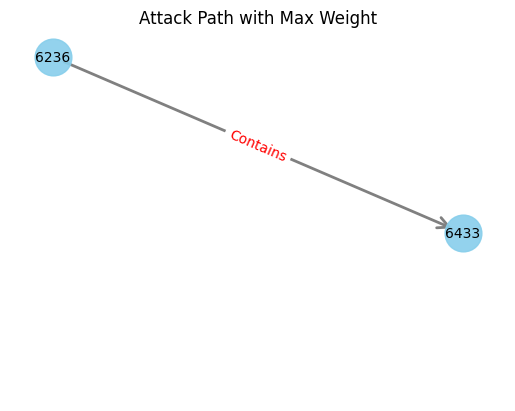

In [60]:
# prompt: using the data in max_weight draw the attack path

import matplotlib.pyplot as plt

# Create a new graph for visualization
viz_G = nx.DiGraph()

# Add nodes from the path to the visualization graph
for node_id in path_ids_min:
    node_properties = nodes[nodes['id'] == node_id]['properties'].iloc[0]
    viz_G.add_node(node_id, properties=node_properties)

# Add edges from the path to the visualization graph
for i in range(len(path_ids_min) - 1):
    start_node = path_ids_min[i]
    end_node = path_ids_min[i+1]
    # Find the edge label and weight from the original edges DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    viz_G.add_edge(start_node, end_node, label=edge_info['label'], weight=edge_info['weight'])

# Define a layout for the graph
pos = nx.spring_layout(viz_G, seed=41) # You can choose different layouts

# Draw the nodes
nx.draw_networkx_nodes(viz_G, pos, node_size=700, node_color='skyblue', alpha=0.9)

# Draw the edges
nx.draw_networkx_edges(viz_G, pos, edgelist=viz_G.edges(), arrowstyle='->', arrowsize=20, edge_color='gray', width=2)

# Draw node labels (using node IDs)
node_labels = {node: node for node in viz_G.nodes()}
nx.draw_networkx_labels(viz_G, pos, labels=node_labels, font_size=10, font_color='black')

# Draw edge labels (using edge labels from the original data)
edge_labels = nx.get_edge_attributes(viz_G, 'label')
nx.draw_networkx_edge_labels(viz_G, pos, edge_labels=edge_labels, font_color='red')

# Add a title to the plot
plt.title("Attack Path with Max Weight")

# Turn off the axis
plt.axis('off')

# Display the plot
plt.show()

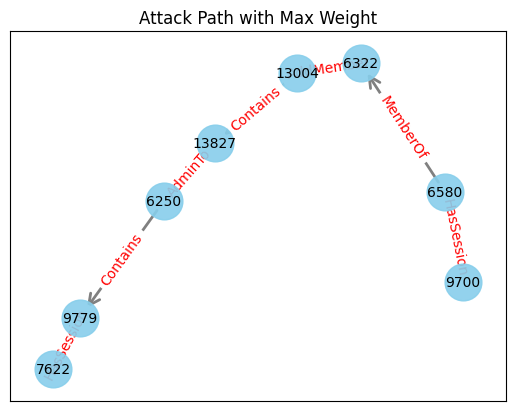

In [67]:
# prompt: using the data in max_weight draw the attack path

import matplotlib.pyplot as plt

# Create a new graph for visualization
viz_G = nx.DiGraph()

# Add nodes from the path to the visualization graph
for node_id in path_ids_max:
    node_properties = nodes[nodes['id'] == node_id]['properties'].iloc[0]
    viz_G.add_node(node_id, properties=node_properties)

# Add edges from the path to the visualization graph
for i in range(len(path_ids_max) - 1):
    start_node = path_ids_max[i]
    end_node = path_ids_max[i+1]
    # Find the edge label and weight from the original edges DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    viz_G.add_edge(start_node, end_node, label=edge_info['label'], weight=edge_info['weight'])

# Define a layout for the graph
pos = nx.spring_layout(viz_G, seed=1) # You can choose different layouts

# Draw the nodes
nx.draw_networkx_nodes(viz_G, pos, node_size=700, node_color='skyblue', alpha=0.9)

# Draw the edges
nx.draw_networkx_edges(viz_G, pos, edgelist=viz_G.edges(), arrowstyle='->', arrowsize=20, edge_color='gray', width=2)

# Draw node labels (using node IDs)
node_labels = {node: node for node in viz_G.nodes()}
nx.draw_networkx_labels(viz_G, pos, labels=node_labels, font_size=10, font_color='black')

# Draw edge labels (using edge labels from the original data)
edge_labels = nx.get_edge_attributes(viz_G, 'label')
nx.draw_networkx_edge_labels(viz_G, pos, edge_labels=edge_labels, font_color='red')

# Add a title to the plot
plt.title("Attack Path with Max Weight")

# Turn off the axis
plt.axis('on')

# Display the plot
plt.show()